In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from tqdm import tqdm

from pulse_analysis import read_root_file, format_root_data
from pulse_analysis import find_hits

# Load data

In [2]:
max_events = 10000

filename = '/disk/gfs_atp/lhoetz/marmotx/XDetector_DC_OR_800V/XDetector_DC_OR_800V_Module_0_0.root'
_ar = read_root_file(filename, max_events=max_events)
data = format_root_data(_ar, n_baseline_samples=50)

n = data['wfs_raw'].shape[0]
n_samples = data['wfs_raw'].shape[-1]

Raw file keys: ['t1;8', 't1;7']
Number of events: 10000
Sample length: 200
Data shape: (10000, 2, 200)


In [3]:
n_sigma_hitfinder_threshold = 4
hits = find_hits(data, n_sigma_hitfinder_threshold=n_sigma_hitfinder_threshold)

100%|██████████| 10000/10000 [00:01<00:00, 6074.81it/s]


# Plot pulses

In [19]:
hits[0]

np.void((0, 1776779140.0, 1, 1363.4443359375, 66, 73, 56, 93), dtype=[('event_index', '<i4'), ('event_time', '<f8'), ('channel', '<i2'), ('hit_area_raw', '<f8'), ('hit_start', '<i2'), ('hit_end', '<i2'), ('hit_left_bound', '<i2'), ('hit_right_bound', '<i2')])

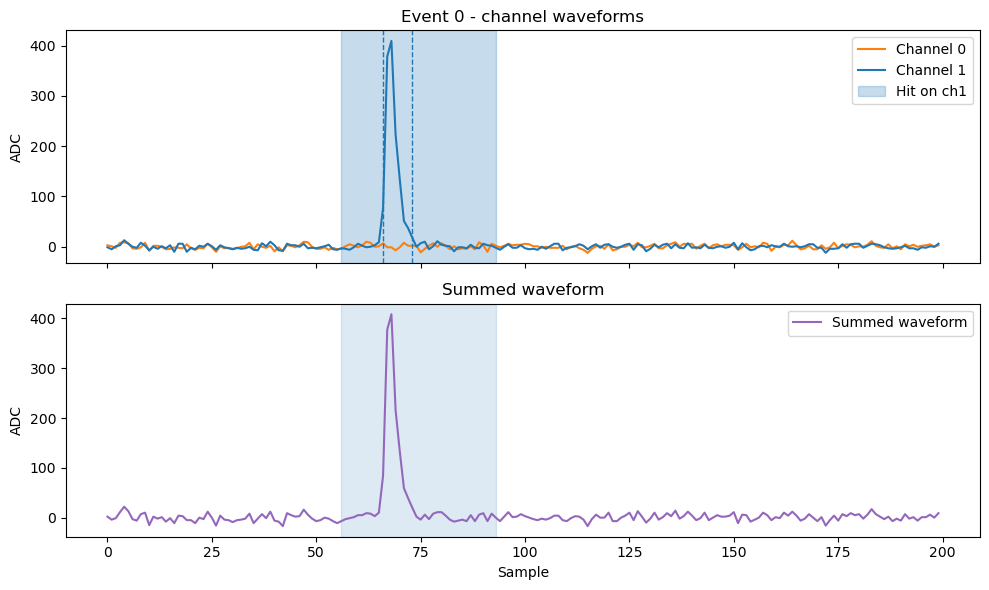

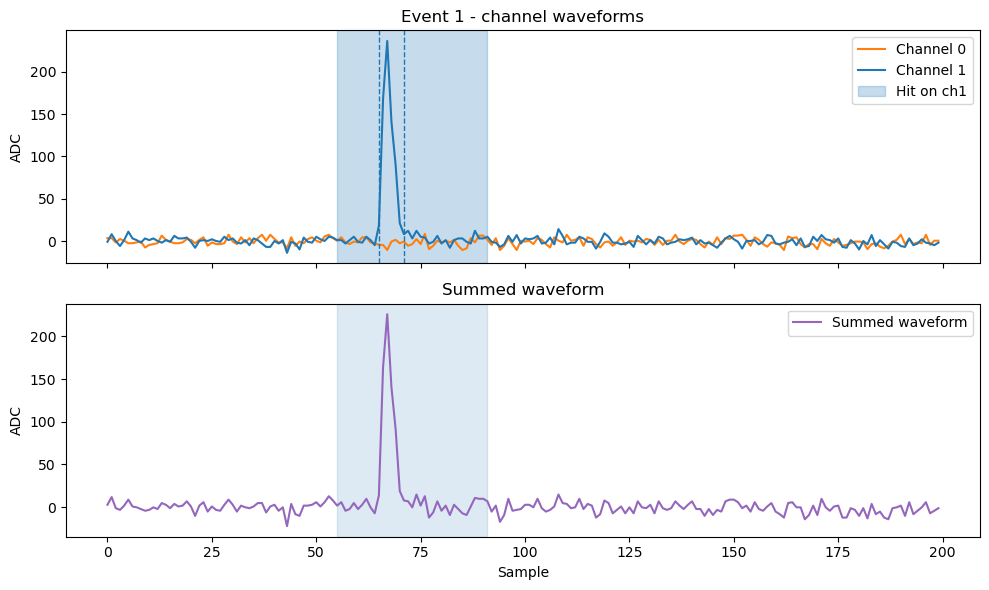

In [20]:
import matplotlib.pyplot as plt

n_pulses_plot = 2

for i in range(n_pulses_plot):
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=False)

    event_id = data["event_index"][i]

    ch0_wf = data["wfs"][i, 0, :]
    ch1_wf = data["wfs"][i, 1, :]
    summed_wf = ch0_wf + ch1_wf

    axs[0].plot(ch0_wf, label="Channel 0", color="tab:orange")
    axs[0].plot(ch1_wf, label="Channel 1", color="tab:blue")

    axs[1].plot(summed_wf, label="Summed waveform", color="tab:purple")

    # hits belonging to this event
    event_hits = hits[hits["event_index"] == event_id]

    for hit in event_hits:
        left = int(hit["hit_left_bound"])
        right = int(hit["hit_right_bound"])
        ch = int(hit["channel"])

        if ch == 0:
            color = "tab:orange"
            label = "Hit on ch0"
            ax = axs[0]
        elif ch == 1:
            color = "tab:blue"
            label = "Hit on ch1"
            ax = axs[0]
        else:
            color = "tab:gray"
            label = f"Hit on ch{ch}"
            ax = axs[0]

        ax.axvspan(left, right, color=color, alpha=0.25, label=label)
        ax.axvline(int(hit["hit_start"]), color=color, ls="--", lw=1)
        ax.axvline(int(hit["hit_end"]), color=color, ls="--", lw=1)

        # also shade on the summed waveform
        axs[1].axvspan(left, right, color=color, alpha=0.15)

    axs[0].set_title(f"Event {event_id} - channel waveforms")
    axs[1].set_title("Summed waveform")

    axs[1].set_xlabel("Sample")
    axs[0].set_ylabel("ADC")
    axs[1].set_ylabel("ADC")

    axs[0].legend()
    axs[1].legend()

    plt.tight_layout()
    plt.show()